In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

plt.style.use("ggplot")

trace = "9bc86d6cd1ee254aaa313492f0fd88be8bd7b92d50d4237ff52d7685440c0906"
t2 = "734272c01926d19690e5ec308bab64ef97950b75b1c7582283e0783fce1751d8"

# trace with the highest number of invocations
t_max = "155e47f8e7f751d0c845049456d01832013c61336a8cd85901330ac821a71534"

df = pd.read_csv(
    "data/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
)


#df["end_timestamp"] = pd.to_timedelta(df["end_timestamp"], unit="seconds")
df["start_timestamp"] = df["end_timestamp"] - df["duration"]
df

,app,func,end_timestamp,duration,start_timestamp
0,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,e3cdb48830f66eb8689cc0223514569a69812b77e6611e...,7.949090e-02,0.078,1.490900e-03
1,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,337cd24a7d5fd5c92460faee4ebe6a186a0eb322bd17b7...,5.715786e+01,57.154,3.860041e-03
2,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037...,5.913048e+01,59.125,5.477905e-03
3,f274d71de386ccc77e4ca74766dbc485461c3053059d47...,3d2aee54a133509f16fb636d74128c2adcfcac71c6dcef...,6.252541e+00,6.236,1.654107e-02
4,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,68bbfd828223a505d7917339f4656c5f33ff93225cdb9d...,6.682396e-02,0.050,1.682396e-02
...,...,...,...,...,...
1980946,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209597e+06,0.001,1.209597e+06
1980947,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209598e+06,0.001,1.209598e+06
1980948,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06
1980949,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06


## Statistics on Az2021

In [8]:

df["duration"].describe()

count    1.980951e+06
mean     3.347944e+00
std      1.850717e+01
min      0.000000e+00
25%      1.000000e-03
50%      3.100000e-02
75%      3.720000e-01
max      5.786200e+02
Name: duration, dtype: float64

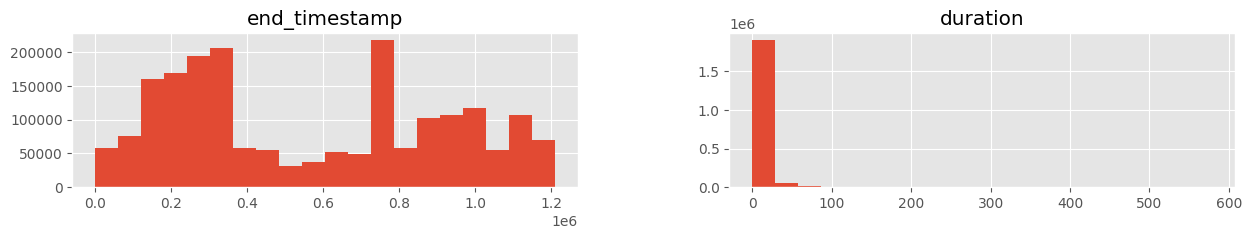

In [9]:
df.hist(column=["end_timestamp", "duration"], layout=[1, 2], figsize=[15, 2], bins=20)
plt.show()

# Duration distribution

In [10]:
def get_cdf(df, field):
    vals = sorted(df[field].values)
    invs = 100.0 * np.arange(0, len(df)) / len(df)
    return vals, invs

In [11]:
def plt_cdf(df, field="duration", title="Duration"):
    
    df_tokens, df_inv = get_cdf(df, field)
    plt.plot(df_tokens, df_inv)
    plt.title(title)
    plt.ylabel("CDF")
    plt.xlabel("Duration")
    plt.grid()
    plt.show()

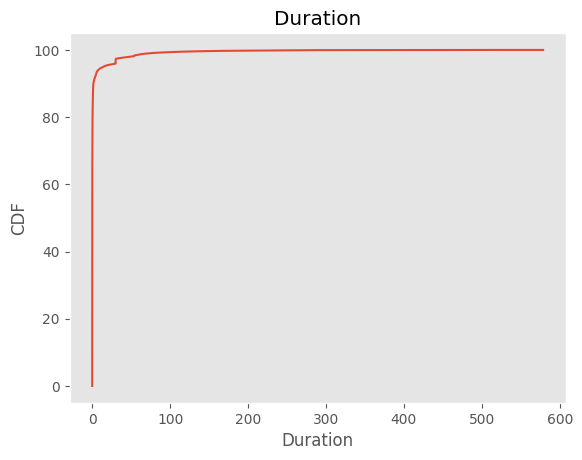

In [12]:
plt_cdf(df, field="duration")

In [13]:
print(f"unique apps: {df["app"].nunique()}, unique funcs: {df["func"].nunique()}")
# df.groupby("app")["func"].count() # num of times an app is invoked
fndf = df.groupby("func")["app"].count() # num of times a function is invoked
print(fndf.sort_values())

unique apps: 119, unique funcs: 424
func
022cdd4cd3ed0302a5ca116eccf280f1d19680123d58e001d04630605ba3e1f8         1
03e6f2ee02dabf9c7d4706ed3eef31ba6cbb3749b2f80d5524de2ade586aec5c         1
1e7621e92fd24b589f58b7a1cca543d9c9090ef7eec6c155414f104a61c0b5fb         1
f00458980c54c85f3edeac151281e50ccaa872d12bcff47f27b4ae78ad7f4d89         1
d776907166edfe3772c93e3c7521f139d063952b3393aef7891fca0c7de9b284         1
                                                                     ...  
bd5be891d0d10fbc3c59215d5f8159ea496433bc41adba7d8d10ea21d35c3e3a    116130
4753d9ffc8a362eadfb27498581969561c0ddbec7257759dbcb9936e506aff82    124143
cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bacfcb712e2be87eef842    142856
8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f476e3914cae25bd2aae    212755
155e47f8e7f751d0c845049456d01832013c61336a8cd85901330ac821a71534    535667
Name: app, Length: 424, dtype: int64


In [20]:
df_s = df[["func", "start_timestamp"]]
df2 = df_s.loc[df_s["func"] == trace]
df_max = df_s.loc[df_s["func"] == t_max]

df2["start_timestamp"] = pd.to_datetime(df2["start_timestamp"], unit="s")
df2 = df2.set_index("start_timestamp")

dfc = df2.resample("5min").count()
dfc = dfc.reset_index()
print(dfc)

        start_timestamp  func
0   1970-01-01 00:00:00     8
1   1970-01-01 00:05:00     8
2   1970-01-01 00:10:00     8
3   1970-01-01 00:15:00     8
4   1970-01-01 00:20:00     8
..                  ...   ...
624 1970-01-03 04:00:00    10
625 1970-01-03 04:05:00    14
626 1970-01-03 04:10:00    12
627 1970-01-03 04:15:00    11
628 1970-01-03 04:20:00     8

[629 rows x 2 columns]


/tmp/ipykernel_1877433/2527062749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["start_timestamp"] = pd.to_datetime(df2["start_timestamp"], unit="s")


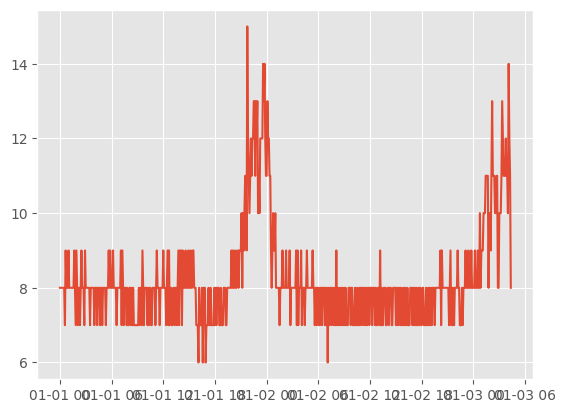

In [15]:
plt.style.use('ggplot')
plt.plot(dfc['start_timestamp'], dfc['func'])

In [16]:
df_max["start_timestamp"] = pd.to_datetime(df_max["start_timestamp"], unit="s")
df_max = df_max.set_index("start_timestamp")

dfc_max = df_max.resample("5min").count()
dfc_max = df_max.reset_index()
print(dfc_max)

                     start_timestamp  \
0      1970-01-01 01:47:09.368362011   
1      1970-01-01 01:47:10.616194014   
2      1970-01-01 01:47:10.960727900   
3      1970-01-01 01:47:12.308424992   
4      1970-01-01 01:47:12.589627909   
...                              ...   
535662 1970-01-14 23:59:56.700016903   
535663 1970-01-14 23:59:58.190409111   
535664 1970-01-14 23:59:58.560518908   
535665 1970-01-14 23:59:58.627381968   
535666 1970-01-14 23:59:59.693463969   

                                                     func  
0       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
1       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
2       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
3       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
4       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
...                                                   ...  
535662  155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
535663  155e47f8e7f751d0c845049456d0183

/tmp/ipykernel_1877433/3524817380.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_max["start_timestamp"] = pd.to_datetime(df_max["start_timestamp"], unit="s")


## Forecasting with ??? methods

16:13:42 - cmdstanpy - INFO - Chain [1] start processing
16:13:42 - cmdstanpy - INFO - Chain [1] done processing


                     ds   y
0   1970-01-01 00:00:00   8
1   1970-01-01 00:05:00   8
2   1970-01-01 00:10:00   8
3   1970-01-01 00:15:00   8
4   1970-01-01 00:20:00   8
..                  ...  ..
624 1970-01-03 04:00:00  10
625 1970-01-03 04:05:00  14
626 1970-01-03 04:10:00  12
627 1970-01-03 04:15:00  11
628 1970-01-03 04:20:00   8

[629 rows x 2 columns]


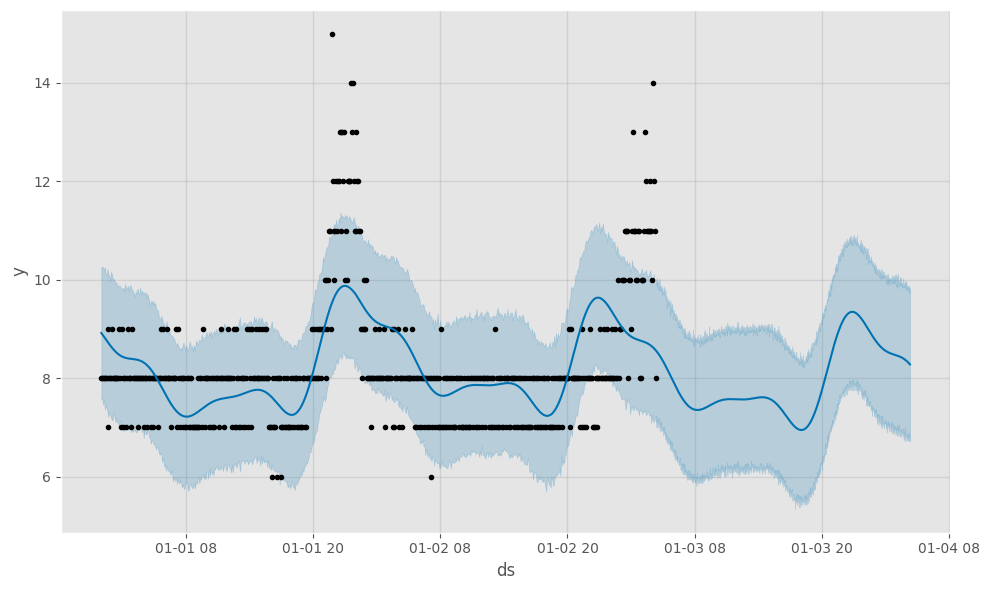

In [ ]:
# Specifying the changepoint brings down the trend line at the end
m = Prophet(changepoints='1970-01-02')

dfp = dfc.rename(columns={"start_timestamp": "ds", "func": "y"})

print(dfp)
m.fit(dfp)

future = m.make_future_dataframe(periods=24*60, freq='min')
future.tail()

forecast = m.predict(future)

fig1 = m.plot(forecast)


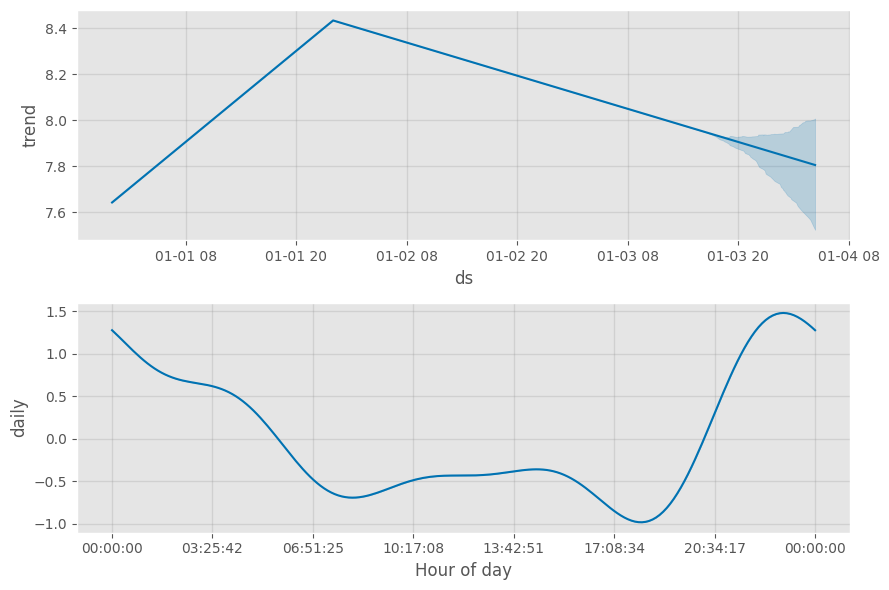

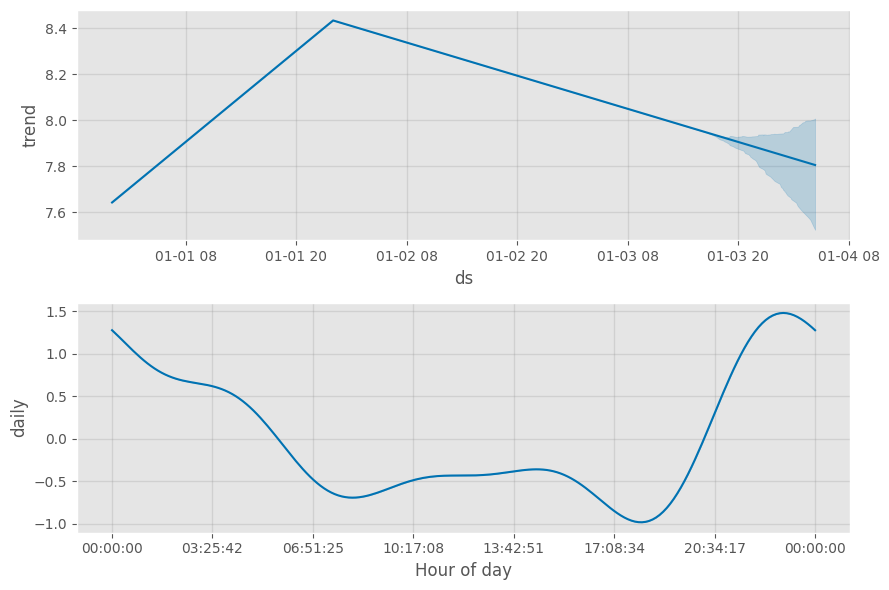

In [11]:
m.plot_components(forecast)